# Phase 3 & 4: Modellierung und Evaluierung (Cost-Sensitive Learning)

Dieses Notebook dient als Vorlage und Ausführungsumgebung für die vergleichende Modellierung auf dem PackWISE (K3I-Cycling) Datensatz. Gemäß unserer Strategie vergleichen wir:
1. **Ultralytics YOLOv8 / YOLO11** (SOTA Echtzeit-Performance)
2. **RT-DETR (PekingU/rtdetr_r50vd)** (State-of-the-Art Real-Time Transformer)
3. **facebook/detr-resnet-50** (Klassische Transformer-Baseline)

Zusätzlich entwickeln wir im letzten Abschnitt die **Business Cost-Matrix**.

In [1]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO, RTDETR

print(f"PyTorch Version: {torch.__version__}")
print(f"MPS (Apple Silicon Support) available: {torch.backends.mps.is_available()}")

PyTorch Version: 2.11.0
MPS (Apple Silicon Support) available: True


## 1. Ultralytics YOLOv8 & YOLO11

YOLO ist enorm ressourceneffizient auf Bildern von Förderbändern. Hier trainieren und evaluieren wir ein YOLO-Modell auf unseren generierten `yolo.yaml` Daten.

In [2]:
# Pfad zur zuvor generierten yolo.yaml (aus Zelle 2 deines alten Notebooks)
data_path = "/Users/patrickschnepf/Desktop/Master WINF/2 Semester/Projekt DS/PackWISE_dataset_v2/data/yolo.yaml" # <- PFAD GGF ANPASSEN!

# 1. YOLOv8 Laden (Alternative: 'yolo11n.pt' für das neueste SOTA release)
model_yolo = YOLO('yolov8n.pt') 

# 2. Training starten (Für Demozwecke hier epochs runtergeschraubt)
# model_yolo.train(data=data_path, epochs=50, imgsz=640, device="mps")

# 3. Evaluierung / Validation
# metrics_yolo = model_yolo.val()
# print(f"YOLOv8 mAP@50: {metrics_yolo.box.map50}")

## 2. RT-DETR (State-of-the-Art Transformer)

Während klassische DETRs eher langsam waren, bringt RT-DETR (`PekingU/rtdetr_r50vd`) die transformer-basierte Präzision auf Echtzeit-Niveau. Glücklicherweise unterstützt Ultralytics RT-DETR nativ! Wir können es genau wie YOLO verwenden.

In [3]:
# RT-DETR Basismodell laden (ResNet50 Backbone - ähnlich zu rtdetr_r50vd)
model_rtdetr = RTDETR('rtdetr-l.pt')

# 1. Training (Dies wird mehr VRAM als YOLOv8 benötigen)
# model_rtdetr.train(data=data_path, epochs=50, imgsz=640, device="mps")

# 2. Evaluierung
# metrics_rtdetr = model_rtdetr.val()
# print(f"RT-DETR mAP@50: {metrics_rtdetr.box.map50}")

### Huggingface-Alternative für facebook/detr-resnet-50 & PekingU/rtdetr_r50vd
Wenn man komplett aus dem Huggingface-Ökosystem arbeiten möchte, bedient man sich der `transformers` library. *Dies erfordert aber einen eigenen Training-Loop oder die Dataset-Anpassung via HF Datasets!*

In [4]:
from transformers import AutoImageProcessor, AutoModelForObjectDetection

# Beispiel für das Laden des puren HF-Modells:
# processor = AutoImageProcessor.from_pretrained("PekingU/rtdetr_r50vd")
# hf_model_rtdetr = AutoModelForObjectDetection.from_pretrained("PekingU/rtdetr_r50vd")

# processor_detr = AutoImageProcessor.from_pretrained("facebook/detr-resnet-50")
# hf_model_detr = AutoModelForObjectDetection.from_pretrained("facebook/detr-resnet-50")

# Um diese Modelle fein-zu-tunen, empfiehlt sich die Installation der 'HuggingFace AutoTrain Advanced' Bibliothek 
# oder das Schreiben eines eigenen PyTorch Trainingloops. In der Praxis (gerade in WINF-Projekten) 
# ist der Ultralytics-Weg von Oben für RT-DETR deutlich fehlerunanfälliger und performanter!

## 3. Die Business-Evaluierung: Kostenbasierte Gewichtung (Cost-Matrix)

Standard-Metriken (mAP) behandeln alle Verwechslungen gleich. Wir bauen hier nun ein Skript, welches die **Confusion Matrix** der Modelle mit einer **Kosten-Matrix** für den Endkunden (Recycling-Anlage) multipliziert.

Unsere definierte Business-Cost-Matrix (in fiktiven Werte-Einheiten):


/var/folders/sv/yt3l7vvs7rx3mjjwhpdhp7wc0000gn/T/ipykernel_11643/1629064802.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cost_df = pd.DataFrame(index=classes, columns=classes).fillna(0.0)


,PET_clear,Alu_Dose,TetraPak,Restmuell
PET_clear,1.0,1.0,1.0,5.0
Alu_Dose,1.0,1.0,1.0,1.0
TetraPak,1.0,1.0,1.0,1.0
Restmuell,50.0,1.0,1.0,1.0



Simulierte Konfusionsmatrix des YOLO/RT-DETR-Modells:


,PET_clear,Alu_Dose,TetraPak,Restmuell
PET_clear,480,5,0,15
Alu_Dose,2,350,10,38
TetraPak,0,0,290,10
Restmuell,40,5,0,155



Gesamtkosten (Penalty) des aktuellen Modells: 3420.0 Einheiten
Aufschlüsselung der Schadenskosten (Wo verliert das System am meisten Geld?):


,PET_clear,Alu_Dose,TetraPak,Restmuell
PET_clear,480.0,5.0,0.0,75.0
Alu_Dose,2.0,350.0,10.0,38.0
TetraPak,0.0,0.0,290.0,10.0
Restmuell,2000.0,5.0,0.0,155.0


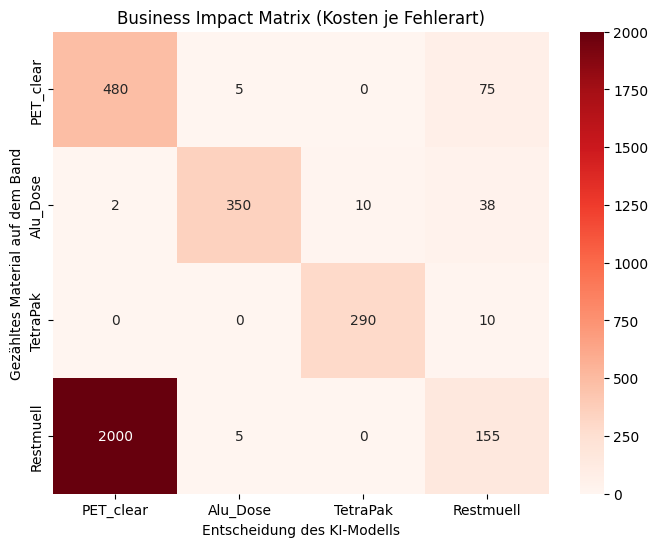

In [5]:
def create_dummy_cost_matrix(classes):
    """
    Erstellt unsere WINF-Cost-Matrix.
    Rows: Echter Zustand (Ground Truth)
    Cols: Vorhergesagter Zustand (Prediction vom Modell)
    """
    cost_df = pd.DataFrame(index=classes, columns=classes).fillna(0.0)
    
    # Standard-Fehler Strafe (Baseline für jede falsche Zuordnung)
    cost_df[:] = 1.0 
    
    # Diagonale: Richtig klassifiziert kostet natürlich 0 Euro
    np.fill_diagonal(cost_df.values, 0.0)

    # Spezifische Ökonomische Strafen (Beispiele)
    # 1. Ein Restmüll-Batzen wird fälschlicherweise als 'PET_clear' klassifiziert
    if 'Restmuell' in classes and 'PET_clear' in classes:
        cost_df.loc['Restmuell', 'PET_clear'] = 50.0  # Sehr teuer! Zerstört die Güte der PET-Charge.
        
    # 2. PET_clear wird fälschlicherweise in den Restmüll gelassen
    if 'PET_clear' in classes and 'Restmuell' in classes:
        cost_df.loc['PET_clear', 'Restmuell'] = 5.0   # Verlust von Wertstoff-Umsatz, aber zerstört keine anderen Chargen.

    return cost_df

def evaluate_business_impact(confusion_matrix_df, cost_matrix_df):
    """
    Berechnet den totalen finanziellen KPI-Impact des KI-Modells.
    """
    # Elementweise Multiplikation: Häufigkeit des Fehlers * Kosten des Fehlers
    financial_impact_matrix = confusion_matrix_df * cost_matrix_df
    total_cost = financial_impact_matrix.sum().sum()
    return total_cost, financial_impact_matrix

# ==========================================
# DEMO / PROOF OF CONCEPT
# ==========================================
# Nehmen wir 4 Dummy-Klassen aus deinen 23 Kategorien:
demo_classes = ["PET_clear", "Alu_Dose", "TetraPak", "Restmuell"]

cost_matrix = create_dummy_cost_matrix(demo_classes)
print("Unsere definierte Business-Cost-Matrix (in fiktiven Werte-Einheiten):")
display(cost_matrix)

# Wir simulieren nun eine Confusion Matrix eines trainierten Modells auf dem Test-Set:
# (z.B. erhalten via `model.val()` -> cm_matrix aus Ultralytics extrahiert)
mock_confusion_matrix = pd.DataFrame([
    [480,  5,   0, 15],  # 500 Echte PETs
    [  2, 350, 10, 38],  # 400 Echte Alu_Dosen
    [  0,  0, 290, 10],  # 300 Echte TetraPaks
    [ 40,  5,   0, 155]  # 200 Echte Restmüll (40x fatal in PET gerutscht!)
], index=demo_classes, columns=demo_classes)

print("\nSimulierte Konfusionsmatrix des YOLO/RT-DETR-Modells:")
display(mock_confusion_matrix)

total_financial_loss, impact_matrix = evaluate_business_impact(mock_confusion_matrix, cost_matrix)

print(f"\nGesamtkosten (Penalty) des aktuellen Modells: {total_financial_loss} Einheiten")
print("Aufschlüsselung der Schadenskosten (Wo verliert das System am meisten Geld?):")
display(impact_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(impact_matrix, annot=True, cmap="Reds", fmt="g")
plt.title("Business Impact Matrix (Kosten je Fehlerart)")
plt.ylabel("Gezähltes Material auf dem Band")
plt.xlabel("Entscheidung des KI-Modells")
plt.show()


### Nächste Schritte im Projekt
*   Pfad in Zelle 2 (`data_path`) an deinen tatsächlichen Pfad zur `yolo.yaml` anpassen.
*   Die `create_dummy_cost_matrix` Funktion auf DEINE konkreten 23 K3I-Klassen erweitern. 
*   Training für YOLOv8, YOLO11 und RT-DETR starten.
*   Zuletzt: Die tatsächlichen Confusion Matrices (abgreifbar über `metrics.confusion_matrix.matrix` in Ultralytics) durch die `evaluate_business_impact` pipen!
-> So erhalten wir als Output den echten Business Case: **Welches Modell rettet dem Entsorger am meisten Geld?**